In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Load data
df = pd.read_csv(r"C:\Users\hp\Pictures\brent-change-point\brent-change-point\data\raw\BrentOilPrices.csv")

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Set index
df.set_index('Date', inplace=True)

print(df.head())


C:\Users\hp\AppData\Local\Temp\ipykernel_4964\3441892249.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


            Price
Date             
1987-05-20  18.63
1987-05-21  18.45
1987-05-22  18.55
1987-05-25  18.60
1987-05-26  18.63


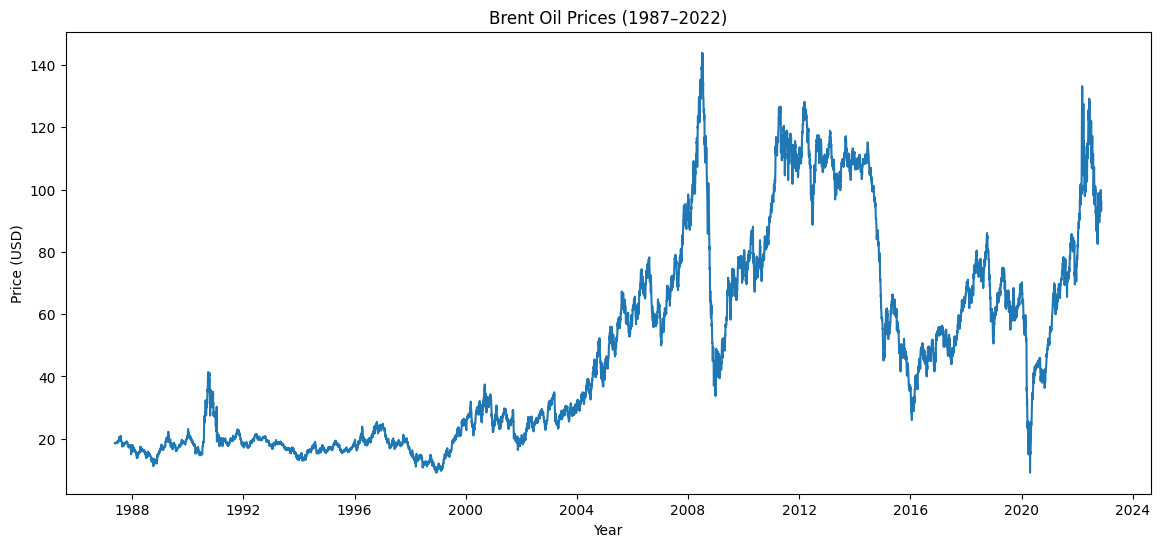

In [2]:
#Plot Raw Price Series
plt.figure(figsize=(14,6))
plt.plot(df.index, df['Price'])
plt.title("Brent Oil Prices (1987–2022)")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.show()

In [3]:
#Log Returns
df['log_price'] = np.log(df['Price'])
df['log_return'] = df['log_price'].diff()

df = df.dropna()

In [4]:
#Stationarity Test
result = adfuller(df['log_return'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -16.427113494485894
p-value: 2.4985801611428892e-29


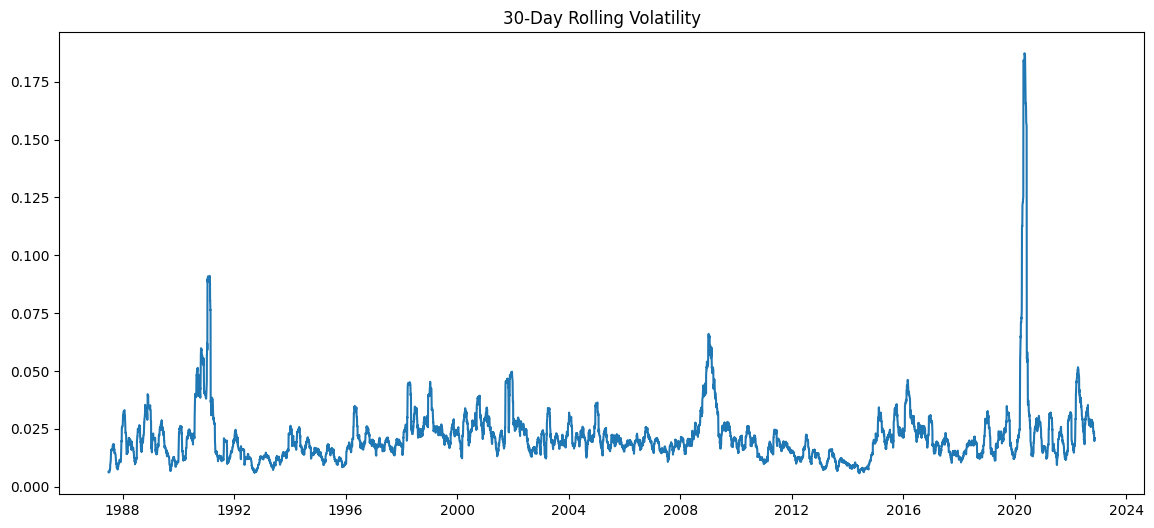

In [5]:
#Volatility Clustering
df['rolling_vol'] = df['log_return'].rolling(30).std()

plt.figure(figsize=(14,6))
plt.plot(df.index, df['rolling_vol'])
plt.title("30-Day Rolling Volatility")
plt.show()